In [17]:
import requests
import csv
import matplotlib.pyplot

   

1 Stockholm
2 Göteborg
3 Malmö
4 Uppsala
5 Västerås
6 Örebro
7 Linköping
8 Helsingborg
9 Jönköping
10 Norrköping
11 Oslo
12 Copenhagen
13 Helsinki
14 Berlin
15 Paris
16 Amsterdam
17 Madrid
18 Rome
19 Vienna
20 Prague
21 Warsaw
22 Brussels
23 Lisbon
24 Dublin
25 London

Lisbon
PM10: 26.7 µg/m³
pm2_5 11.6 µg/m³
European AQI: 33


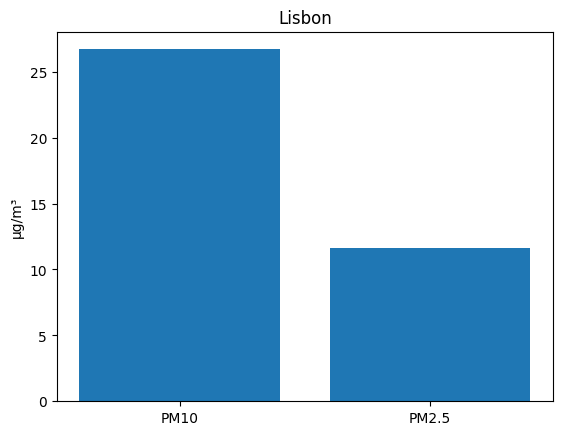

The european air quality indexs is more than 20 but less than 40 (33).
The air quality is fair


In [18]:
class CityControl():

    def cities(): # Gör om till csv fil
        cities = {}


        with open("cities.csv", "r", encoding="utf-8") as csv_file:
            csv_reader = csv.reader(csv_file)
            next(csv_reader)
            for line in csv_reader:
                city = line[0]
                latitude = float(line[1].strip())
                longitude = float(line[2].strip())
                cities[city] = [latitude, longitude]
            return cities


    def print_cities():

        cities = CityControl.cities()
        city_name = list(cities.keys()) # Detta tar cities dict och gör till en lista och lägger till alla key value stockholm, göteborg tex
         
        for number, city in enumerate(city_name, 1):
            print(number, city)


        return city_name

    def choose_city():
    
        cities = CityControl.cities()
        # print(len(cities))
        while True:
                       
            try: 
               

                city_choice = int(input(f"Choice 1-{len(cities)}: ")) # Valda staden som användaren skriver in. måste omvandla dict till lista för att kunna bara ta ut staden

                if city_choice >= 1 and city_choice <= len(cities):
                    return city_choice
                    
                else:
                    print(f"Write a number 1-{len(cities)}")
                    
            except ValueError:
                    print(f"Write a number 1-{len(cities)}")


def website_info(city_name, cities, city_choice):
    selected_city = city_name[city_choice - 1] #  Tar ut ett värde från listan. Eftersom att listor börjar från 0 så måste man ta -1

    # Tar ut longitud och latitud värdet
    latitude = cities[selected_city][0]
    longitude = cities[selected_city][1]

    try:
        get_website = requests.get(f"https://air-quality-api.open-meteo.com/v1/air-quality?latitude={latitude}&longitude={longitude}&current=pm10,pm2_5,european_aqi", timeout=10) # skriver in värdet i adressen så att det passar
        get_website.raise_for_status()
        get_pm_value = get_website.json()
    except requests.exceptions.HTTPError:
        print("Error")
        print(get_website.status_code)
        print(get_website.text)
        return
    except requests.exceptions.RequestException:
        print("A request error occurred:")
        return

    
    pm10 = get_pm_value["current"]["pm10"]
    # print(pm10)

    pm2_5 = get_pm_value["current"]["pm2_5"]
    # print(pm2_5)

    european_aqi = get_pm_value["current"]["european_aqi"]
    # print(european_aqi)

    return pm10, pm2_5, european_aqi, selected_city

    




class Measurement:
    def __init__(self, city):
        self.city = city

    def show_city(self):
        return f"measurement from {self.city}"


class AirQualityMeasurement(Measurement):
    def __init__(self, city, pm10, pm2_5, european_aqi):
        super().__init__(city)
        self.pm10 = pm10
        self.pm2_5 = pm2_5
        self.european_aqi = european_aqi


    def add_data_to_csv(self):
        with open("air_quality_data.csv", "a", newline="", encoding="utf-8") as csv_file:
            writer = csv.writer(csv_file)
            writer.writerow([self.city, self.pm10, self.pm2_5, self.european_aqi])



    def current_measurement(self):
        
        print("")
        print(self.city)
        print(f"PM10: {self.pm10} µg/m³")
        print(f"pm2_5 {self.pm2_5} µg/m³")
        print(f"European AQI: {self.european_aqi}")

    def get_aqi_status(self):
        if self.european_aqi <= 20: 
            return(f"The european air quality indexs is less than 20 ({self.european_aqi}).\nThe air quality is good")

        elif self.european_aqi <= 40:
            return(f"The european air quality indexs is more than 20 but less than 40 ({self.european_aqi}).\nThe air quality is fair")

        elif self.european_aqi <= 60:
            return(f"The european air quality indexs is more than 40 but less than 60 ({self.european_aqi}).Consider reducing intense outdoor activities if you experience symptoms.\nThe air quality is Moderate")

        elif self.european_aqi <= 80:
            return(f"The european air quality indexs is more than 60 but less than 80 ({self.european_aqi}).Consider reducing physical activities, particularly outdoors, especially if you experience symptoms. \nThe air quality is poor")

        elif self.european_aqi <= 100:
            return(f"The european air quality indexs is more than 80 but less than 100 ({self.european_aqi}) Consider reducing physical activities, particularly outdoors, especially if you experience symptoms. \nThe air quality is very poor")
        else:
            return(f"The european air quality indexs is more than 100 ({self.european_aqi}) Avoid physical activities outdoors. \nThe air quality is extremely poor")


    def show_chart(self):
        lables = ["PM10", "PM2.5"]
        values = [self.pm10, self.pm2_5]

        matplotlib.pyplot.bar(lables, values)
        matplotlib.pyplot.ylabel("µg/m³")
        matplotlib.pyplot.title(self.city)
        matplotlib.pyplot.show()


def main():
    cities = CityControl.cities()
    city_name = CityControl.print_cities()
    chosen_city = CityControl.choose_city()
    result = website_info(city_name, cities, chosen_city)
    
    if result is None:
        print("Something went wrong. Try again later.")
        return

    else:
        pm10, pm2_5, european_aqi, selected_city = result
        current_AQ_reading = AirQualityMeasurement(selected_city, pm10, pm2_5, european_aqi)
        current_AQ_reading.add_data_to_csv()
        current_AQ_reading.current_measurement()
        aqi_status = current_AQ_reading.get_aqi_status()
        current_AQ_reading.show_chart()
        print(aqi_status)
    

main()
